SINTESIS FINAL TP ALC 'ESPADAS DE MIQUELLA'--------------------------------

In [10]:
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from alc import *
try:
    from tqdm.auto import tqdm
except ImportError:
    from tqdm import tqdm

-- Cargamos y guardamos los embeddings etiquetados

In [7]:
carpeta='cats_and_dogs/'
X_t, y_t,X_v, y_v = cargarDatos(carpeta)

-- Creamos matriz de confusion para cada metodo --


Matriz de Confusión:
      | Pred G | Pred P
Real G|    334 |    166
Real P|    150 |    350
Accuracy: 68.40%


<function matplotlib.pyplot.show(close=None, block=None)>

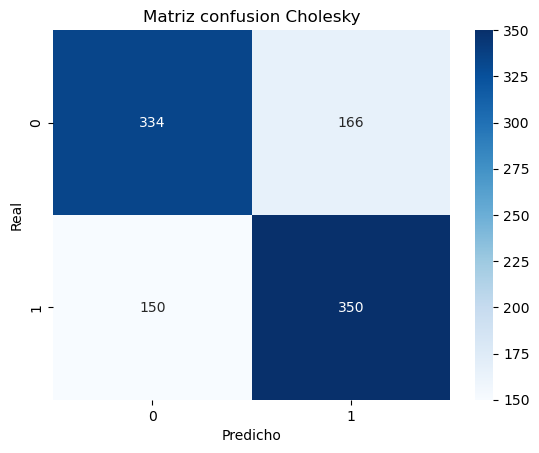

In [ ]:
#-- Matriz de confusion para el metodo con Ecuaciones Normales
#-- tiempo de ejecucion (@) == 19m 24.2s y accuracy == 68.40
W_Ch = calculo_peso_W(X_t,y_t)
m_confusion_cholesky = matriz_confusion(W_Ch,X_v,y_v)
sns.heatmap(data= m_confusion_cholesky, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz confusion Cholesky')
plt.show

Iniciando SVD reducida de matriz (1536, 2000)
  - Calculando AtA
  - Diagonalizando (1536x1536) con k=100
  - Construyendo U (k=100)
  - Paso 1: Y @ V
  - Paso 2: Escalar Sigma
  - Paso 3: Resultado @ U.T

Matriz de Confusión:
      | Pred G | Pred P
Real G|    329 |    171
Real P|    211 |    289
Accuracy: 61.80%


<function matplotlib.pyplot.show(close=None, block=None)>

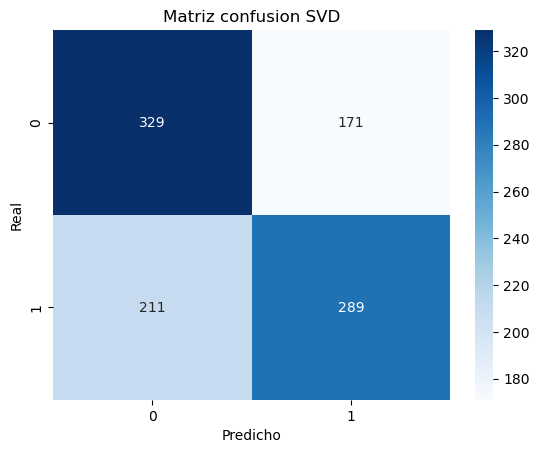

In [8]:
#-- Matriz de confusion para el metodo con Descomposicion SVD
U,E,V = svd_reducida(X_t,100)
W_svd = pinvSVD(U,E,V,y_t)
m_confusion_svd = matriz_confusion(W_svd,X_v,y_v)
sns.heatmap(data= m_confusion_svd, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz confusion SVD')
plt.show

Resolviendo QR con Gram Schmidt:   0%|          | 0/1535 [00:00<?, ?it/s]

Resolviendo pinvQR, metodo: Gram Schmidt:   0%|          | 0/2000 [00:00<?, ?it/s]


Matriz de Confusión:
      | Pred G | Pred P
Real G|     66 |    434
Real P|    125 |    375
Accuracy: 44.10%


<function matplotlib.pyplot.show(close=None, block=None)>

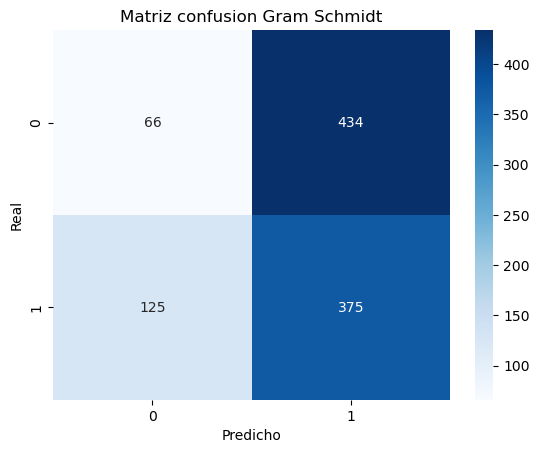

In [ ]:
#-- Matriz de confusion para el metodo de Descomposicion QR con GS
#-- tiempo: 10m 23.0s
Xt_t = traspuesta_(X_t)

#-- Calculamos el QR de los metodos Grand-Schmit y HouseHolder
Q_GS, R_GS = calculaQR(Xt_t, metodo='GS')

#-- Calculamos el peso W con el metodo GS
W_GS = pinvGramSchmidt(Q=Q_GS, R=R_GS, Y=y_t)

#-- Ahora calculamos a la matriz de confusion del metodo GS
m_confusion_gs = matriz_confusion(W_GS, X_v, y_v)
sns.heatmap(data= m_confusion_gs, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz confusion Gram Schmidt')
plt.show


Resolviendo QR con House Holder:   0%|          | 0/1536 [00:00<?, ?it/s]

Resolviendo pinvQR, metodo: House Holder:   0%|          | 0/2000 [00:00<?, ?it/s]


Matriz de Confusión:
      | Pred G | Pred P
Real G|    340 |    160
Real P|    241 |    259
Accuracy: 59.90%


<function matplotlib.pyplot.show(close=None, block=None)>

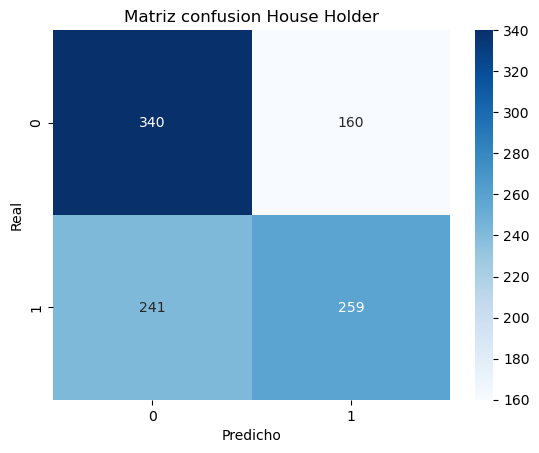

In [ ]:
#-- Matriz de confusion para el metodo de Descomposicion QR con HH
#-- tiempo == 12m 18,5s
Q_HH, R_HH = calculaQR(Xt_t, metodo='RH')

#-- Calculamos el peso W con el metodo HH
W_HH = pinvHouseHolder(Q=Q_HH, R=R_HH, Y=y_t)

#-- Ahora calculamos a la matriz de confusion del metodo HH
m_confusion_hh = matriz_confusion(W_HH, X_v, y_v)
sns.heatmap(data= m_confusion_hh, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz confusion House Holder')
plt.show

In [12]:
data = {
    "Modelo": ["Ecuaciones Normales", "SVD", "QR con GS","QR con HH"],
    "Accuracy (%)": [68.40, 'completar', 44.10, 59.90],
    "Tiempo (m/s)": ['19m 24.2s', 'completar', '10m 23.0s', '12m 18.5s']
}

tabla = pd.DataFrame(data)
print(tabla)

                Modelo Accuracy (%) Tiempo (m/s)
0  Ecuaciones Normales         68.4    19m 24.2s
1                  SVD    completar    completar
2            QR con GS         44.1    10m 23.0s
3            QR con HH         59.9    12m 18.5s


Informe de analisis -- (400 palabras)
